In [9]:
#  PHASE 9 — EVALUATION METRICS & MODEL COMPARISON
#  Notebook : notebooks/09_evaluation_and_comparison.ipynb
#
#  Brings every model into ONE table, tests each one properly
#  with K-Fold Cross-Validation (not just one lucky/unlucky
#  train-test split), checks bias vs variance with a learning
#  curve, and saves the final winning model.
# ================================================================
 
 
# ── CELL 1 — Imports ────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, learning_curve
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')
 
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("Imports done ✓")
 
 

Imports done ✓


In [10]:
# ── CELL 2 — Load Data ───────────────────────────────────────────
train = pd.read_csv(r'C:\git\machine learning\house-price-prediction\data\processed\train.csv')
test  = pd.read_csv(r'C:\git\machine learning\house-price-prediction\data\processed\test.csv')
 
X_train = train.drop(columns=['SalePrice'])
X_test  = test.drop(columns=['SalePrice'])
y_train = train['SalePrice'].values
y_test  = test['SalePrice'].values
 
print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")

X_train : (2341, 188)  |  X_test : (586, 188)


In [11]:
# Same grids as Phase 8. Re-running here keeps this notebook
# self-contained (works even if you open it on its own).
 
ridge_grid = GridSearchCV(Ridge(), {'alpha':[0.001,0.01,0.1,1,5,10,20,50,100]}, cv=5, scoring='r2')
ridge_grid.fit(X_train, y_train)
best_ridge_alpha = ridge_grid.best_params_['alpha']
 
lasso_grid = GridSearchCV(Lasso(max_iter=10000), {'alpha':[0.0001,0.0005,0.001,0.005,0.01,0.05,0.1]}, cv=5, scoring='r2')
lasso_grid.fit(X_train, y_train)
best_lasso_alpha = lasso_grid.best_params_['alpha']
 
elastic_grid = GridSearchCV(ElasticNet(max_iter=10000),
                             {'alpha':[0.0001,0.001,0.01], 'l1_ratio':[0.1,0.5,0.9]},
                             cv=5, scoring='r2')
elastic_grid.fit(X_train, y_train)
best_elastic_params = elastic_grid.best_params_
 
print(f"Best Ridge alpha       : {best_ridge_alpha}")
print(f"Best Lasso alpha       : {best_lasso_alpha}")
print(f"Best ElasticNet params : {best_elastic_params}")
 

Best Ridge alpha       : 10
Best Lasso alpha       : 0.0001
Best ElasticNet params : {'alpha': 0.001, 'l1_ratio': 0.1}


In [12]:
models = {
    'Multiple LR': LinearRegression(),
    'Ridge'      : Ridge(alpha=best_ridge_alpha),
    'Lasso'      : Lasso(alpha=best_lasso_alpha, max_iter=10000),
    'ElasticNet' : ElasticNet(**best_elastic_params, max_iter=10000)
}
print("Models ready:", list(models.keys()))

Models ready: ['Multiple LR', 'Ridge', 'Lasso', 'ElasticNet']


In [13]:
#  MAE  = average size of error, every mistake weighted equally
#  RMSE = punishes BIG mistakes more (because error is squared)
#  R²   = % of price variance explained
 
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)
 
    n_features_used = int(np.sum(model.coef_ != 0))
 
    results.append({
        'Model'    : name,
        'Features' : n_features_used,
        'Train R2' : r2_score(y_train, pred_train),
        'Test R2'  : r2_score(y_test, pred_test),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, pred_test)),
        'Test MAE' : mean_absolute_error(y_test, pred_test)
    })
 
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))
 

             Features  Train R2  Test R2  Test RMSE  Test MAE
Model                                                        
Multiple LR       188    0.9358   0.9523     0.0926    0.0698
Ridge             187    0.9309   0.9529     0.0920    0.0693
Lasso             151    0.9326   0.9527     0.0921    0.0693
ElasticNet        147    0.9314   0.9529     0.0920    0.0693


In [14]:
#
#  One train/test split can be lucky or unlucky (we saw this in
#  Phase 5 — test R² was even HIGHER than train R², just by chance).
#
#  K-Fold CV splits the data into K equal parts. It trains K times,
#  each time holding out a DIFFERENT part as the test set, then
#  averages all K scores. Much more reliable than a single split.
# ────────────────────────────────────────────────────────────────
 
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
 
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='r2')
    cv_results[name] = scores
    print(f"{name:<13} scores: {scores.round(3)}  |  mean: {scores.mean():.4f}  std: {scores.std():.4f}")
 
results_df['CV Mean R2'] = [cv_results[m].mean() for m in results_df.index]
results_df['CV Std R2']  = [cv_results[m].std()  for m in results_df.index]
print("\n", results_df.round(4))

Multiple LR   scores: [0.917 0.897 0.889 0.922 0.874]  |  mean: 0.9000  std: 0.0178
Ridge         scores: [0.927 0.902 0.921 0.931 0.906]  |  mean: 0.9174  std: 0.0114
Lasso         scores: [0.925 0.901 0.921 0.929 0.907]  |  mean: 0.9164  std: 0.0107
ElasticNet    scores: [0.926 0.901 0.921 0.93  0.907]  |  mean: 0.9172  std: 0.0111

              Features  Train R2  Test R2  Test RMSE  Test MAE  CV Mean R2  \
Model                                                                       
Multiple LR       188    0.9358   0.9523     0.0926    0.0698      0.9000   
Ridge             187    0.9309   0.9529     0.0920    0.0693      0.9174   
Lasso             151    0.9326   0.9527     0.0921    0.0693      0.9164   
ElasticNet        147    0.9314   0.9529     0.0920    0.0693      0.9172   

             CV Std R2  
Model                   
Multiple LR     0.0178  
Ridge           0.0114  
Lasso           0.0107  
ElasticNet      0.0111  


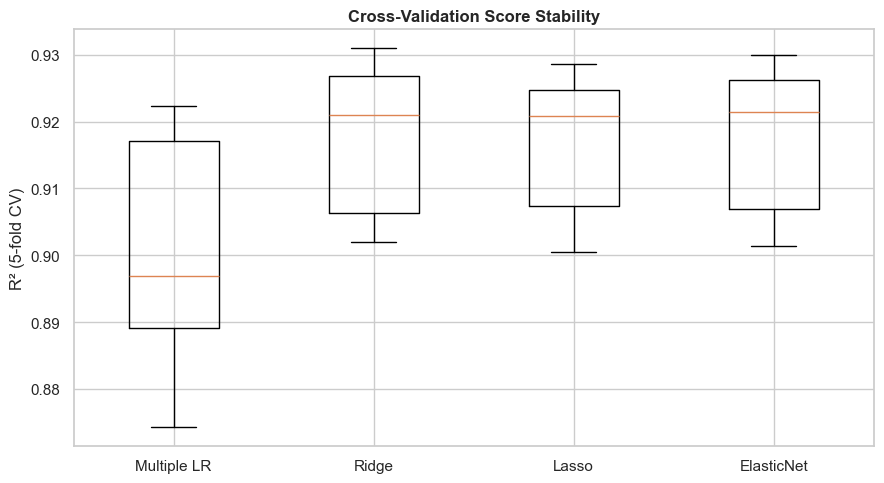

In [15]:
# Short box = stable across folds. Tall box = unreliable, even
# if its average score looks good.
 
plt.figure(figsize=(9, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.ylabel('R² (5-fold CV)')
plt.title('Cross-Validation Score Stability', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\git\machine learning\house-price-prediction\reports\figures\23_cv_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

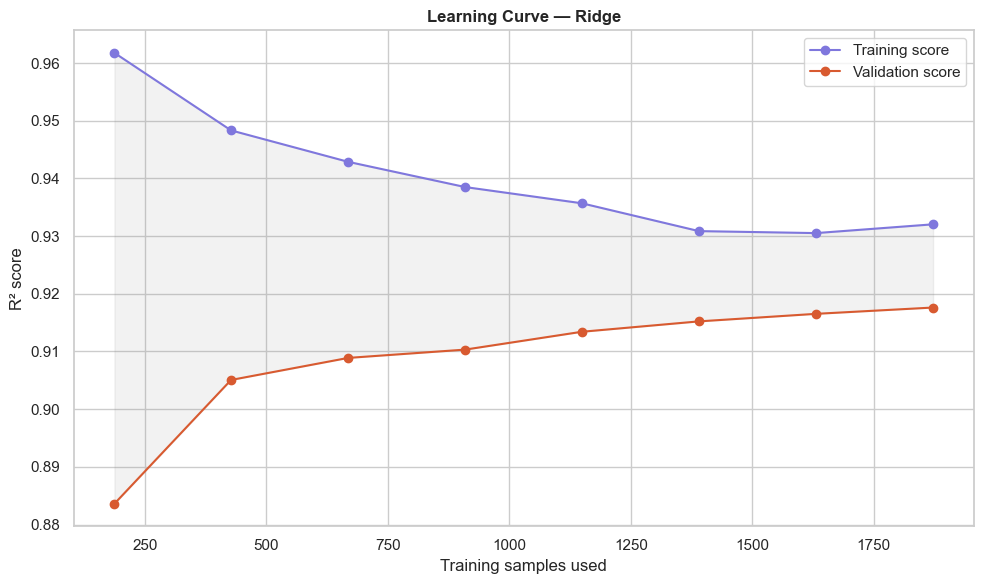

Final train score : 0.9320  |  Final val score : 0.9176  |  Gap : 0.0144
Small gap (<0.05) → low variance, generalises well


In [16]:

#  Trains the model on increasing chunks of data (10%, 20%...100%)
#  and plots train score vs validation score at each size.
#
#  Train & Val both LOW, close together  → HIGH BIAS (underfitting)
#  Train HIGH, Val LOW, big gap          → HIGH VARIANCE (overfitting)
#  Both converge to a good score          → well-fit model
# ────────────────────────────────────────────────────────────────
 
best_model_name = results_df['CV Mean R2'].idxmax()
best_model      = models[best_model_name]
 
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8)
)
train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
 
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#7F77DD', label='Training score')
plt.plot(train_sizes, val_mean,   'o-', color='#D85A30', label='Validation score')
plt.fill_between(train_sizes, train_mean, val_mean, alpha=0.1, color='gray')
plt.xlabel('Training samples used')
plt.ylabel('R² score')
plt.title(f'Learning Curve — {best_model_name}', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\git\machine learning\house-price-prediction\reports\figures\24_learning_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
gap = train_mean[-1] - val_mean[-1]
print(f"Final train score : {train_mean[-1]:.4f}  |  Final val score : {val_mean[-1]:.4f}  |  Gap : {gap:.4f}")
print("Small gap (<0.05) → low variance, generalises well" if gap < 0.05 else "Larger gap → mild overfitting")
 

In [17]:
print("=" * 58)
print(f"  WINNER : {best_model_name}")
print(f"  CV Mean R² : {results_df.loc[best_model_name,'CV Mean R2']:.4f}")
print(f"  Test R²    : {results_df.loc[best_model_name,'Test R2']:.4f}")
print(f"  Test RMSE  : {results_df.loc[best_model_name,'Test RMSE']:.4f}")
print(f"  Features   : {int(results_df.loc[best_model_name,'Features'])}")
print("=" * 58)
 
best_model.fit(X_train, y_train)
joblib.dump(best_model, r'C:\git\machine learning\house-price-prediction\data\processed\final_model.pkl')
print("\nSaved → data/processed/final_model.pkl")
print("Phase 9 complete ✓  →  Phase 10: Documentation & GitHub Push")
 

  WINNER : Ridge
  CV Mean R² : 0.9174
  Test R²    : 0.9529
  Test RMSE  : 0.0920
  Features   : 187

Saved → data/processed/final_model.pkl
Phase 9 complete ✓  →  Phase 10: Documentation & GitHub Push
